In [ ]:
#-------------------- 1. Importation des librairies pour l'EDA------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


In [25]:
# -----------2. Chargement des données et suppression des colonnes non pertinentes-------------------
df = pd.read_excel(r'C:\Users\pc\Downloads\PROJET_INFO\CODINGWEEKGITHUB2026\notebooks\app_data_sans_critiques.xlsx')
colonnes_a_supprimer = list(set([
    'Peritonitis', 'Weight', 'Height', 'Alvarado_Score', 'Neutrophilia', 'Stool', 'RBC_Count', 'Paedriatic_Appendicitis_Score',
    'Management', 'Severity', 'Length_of_Stay', 'Diagnosis_Presumptive', 'US_Number', 'CRP_log'
]))
df = df.drop(columns=[col for col in colonnes_a_supprimer if col in df.columns])
print("La matrice a été réduite à : ", df.shape)
print("Colonnes restantes : ", df.columns)


La matrice a été réduite à :  (776, 27)
Colonnes restantes :  Index(['Age', 'BMI', 'Sex', 'Diagnosis', 'Appendix_on_US', 'Appendix_Diameter',
       'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Hemoglobin', 'RDW', 'Thrombocyte_Count',
       'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria',
       'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed',
       'Free_Fluids'],
      dtype='object')


In [26]:
# ------------------3. Vérification des valeurs manquantes et doublons---------------------------
print("valeur manquante :", df.isnull().sum())
print("Nombre de lignes en double :", df.duplicated().sum())
total_missing = df.isnull().sum().sum()
total_duplicates = df.duplicated().sum()
if total_missing == 0 and total_duplicates == 0:
    print("Le fichier est bien nettoyé : aucune valeur manquante ni doublon.")
else:
    print(f"Le fichier n'est pas totalement nettoyé : {total_missing} valeurs manquantes, {total_duplicates} doublons.")

valeur manquante : Age                                 0
BMI                                 0
Sex                                 0
Diagnosis                           0
Appendix_on_US                      0
Appendix_Diameter                   0
Migratory_Pain                      0
Lower_Right_Abd_Pain                0
Contralateral_Rebound_Tenderness    0
Coughing_Pain                       0
Nausea                              0
Loss_of_Appetite                    0
Body_Temperature                    0
WBC_Count                           0
Neutrophil_Percentage               0
Hemoglobin                          0
RDW                                 0
Thrombocyte_Count                   0
Ketones_in_Urine                    0
RBC_in_Urine                        0
WBC_in_Urine                        0
CRP                                 0
Dysuria                             0
Psoas_Sign                          0
Ipsilateral_Rebound_Tenderness      0
US_Performed                   

In [27]:
#- ---------------4. Listes des variables numériques et catégorielles-----------------------------
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Variables numériques :", numerical_cols)
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print("Variables catégorielles :", categorical_cols)

Variables numériques : ['Age', 'BMI', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']
Variables catégorielles : ['Sex', 'Diagnosis', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'Dysuria', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids']


In [28]:
#------ -------------------5. Statistiques descriptives-----------------------------------------------
print(df.describe())
print(df.dtypes)

              Age         BMI  Appendix_Diameter  Body_Temperature  \
count  776.000000  776.000000         776.000000        776.000000   
mean    11.345274   18.773462           7.517526         37.417784   
std      3.526092    4.000675           1.250632          0.819390   
min      0.000000    7.961926           5.500000         35.600000   
25%      9.228131   15.797500           7.000000         36.800000   
50%     11.442847   18.062284           7.500000         37.200000   
75%     14.040383   21.021216           8.000000         37.900000   
max     18.360000   28.856790           9.500000         40.200000   

        WBC_Count  Neutrophil_Percentage  Hemoglobin         RDW  \
count  776.000000             776.000000  776.000000  776.000000   
mean    12.609488              72.216753   13.346263   12.893814   
std      5.223045              13.548472    1.116786    0.879846   
min      2.600000              27.200000    8.200000   11.200000   
25%      8.275000            

Diagnosis
appendicitis       461
no appendicitis    315
Name: count, dtype: int64

Proportions (%):
Diagnosis
appendicitis       59.41
no appendicitis    40.59
Name: proportion, dtype: float64


C:\Users\pc\AppData\Local\Temp\ipykernel_7768\4136817777.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette=palette)


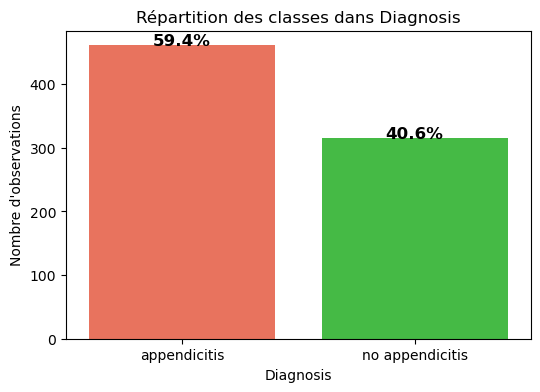

In [29]:
# -----------6. Vérification des déséquilibres des classes (exemple : Diagnosis)-----------------
target_col = 'Diagnosis'
class_counts = df[target_col].value_counts()
class_percent = df[target_col].value_counts(normalize=True) * 100
print(class_counts)
print("\nProportions (%):")
print(class_percent.round(2))

palette = {'appendicitis': 'tomato', 'no appendicitis': 'limegreen'}
#Visualisation
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette=palette)
for i, (count, percent) in enumerate(zip(class_counts, class_percent)):
    plt.text(i, count + 0.5, f'{percent:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.title(f"Répartition des classes dans {target_col}")
plt.xlabel(target_col)
plt.ylabel("Nombre d'observations")
plt.show()

Corrélation avec la cible :
BMI                      0.135533
Age                      0.086372
Hemoglobin               0.018404
Thrombocyte_Count       -0.000441
RDW                     -0.029700
Body_Temperature        -0.149984
CRP                     -0.278897
Neutrophil_Percentage   -0.328858
WBC_Count               -0.362745
Appendix_Diameter       -0.470153
Name: Diagnosis, dtype: float64


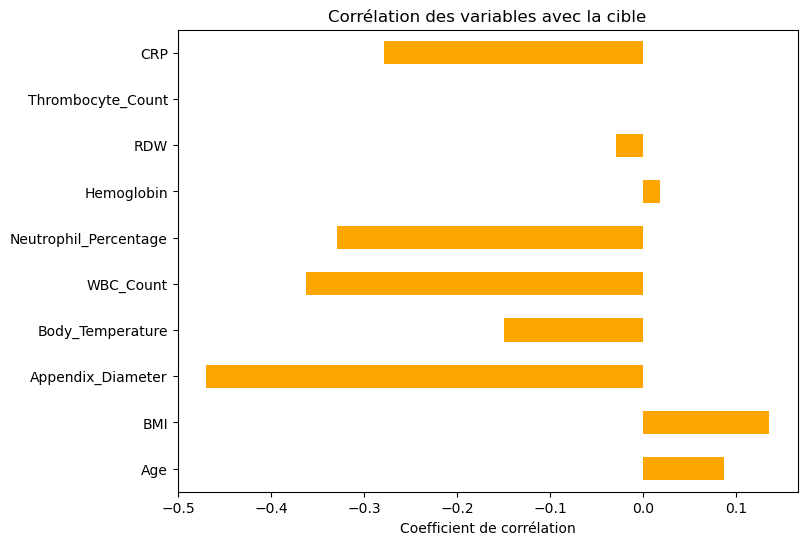

In [30]:
# 7. Identification des features les plus corrélées à la cible
if df['Diagnosis'].dtype == 'object':
    df['Diagnosis'] = LabelEncoder().fit_transform(df['Diagnosis'])
correlation_matrix = df.select_dtypes(include='number').corr()
if target_col in correlation_matrix.columns:
    corr_target = correlation_matrix[target_col].drop(target_col)
    print("Corrélation avec la cible :")
    print(corr_target.sort_values(ascending=False))
    plt.figure(figsize=(8, 6))
    corr_target.plot(kind='barh', color='orange')
    plt.title("Corrélation des variables avec la cible")
    plt.xlabel("Coefficient de corrélation")
    plt.show()
else:
    print("La colonne cible n'est pas numérique ou n'existe pas dans la matrice.")

                            Age       BMI  Diagnosis  Appendix_Diameter  \
Age                    1.000000  0.484780   0.086372          -0.017859   
BMI                    0.484780  1.000000   0.135533           0.013541   
Diagnosis              0.086372  0.135533   1.000000          -0.470153   
Appendix_Diameter     -0.017859  0.013541  -0.470153           1.000000   
Body_Temperature      -0.293591 -0.171773  -0.149984           0.074817   
WBC_Count             -0.249171 -0.130782  -0.362745           0.283515   
Neutrophil_Percentage -0.161119 -0.168393  -0.328858           0.278952   
Hemoglobin             0.346576  0.179594   0.018404           0.010348   
RDW                   -0.115251  0.055643  -0.029700          -0.011698   
Thrombocyte_Count     -0.255215 -0.042370  -0.000441           0.021364   
CRP                   -0.129982 -0.065820  -0.278897           0.191228   

                       Body_Temperature  WBC_Count  Neutrophil_Percentage  \
Age                   

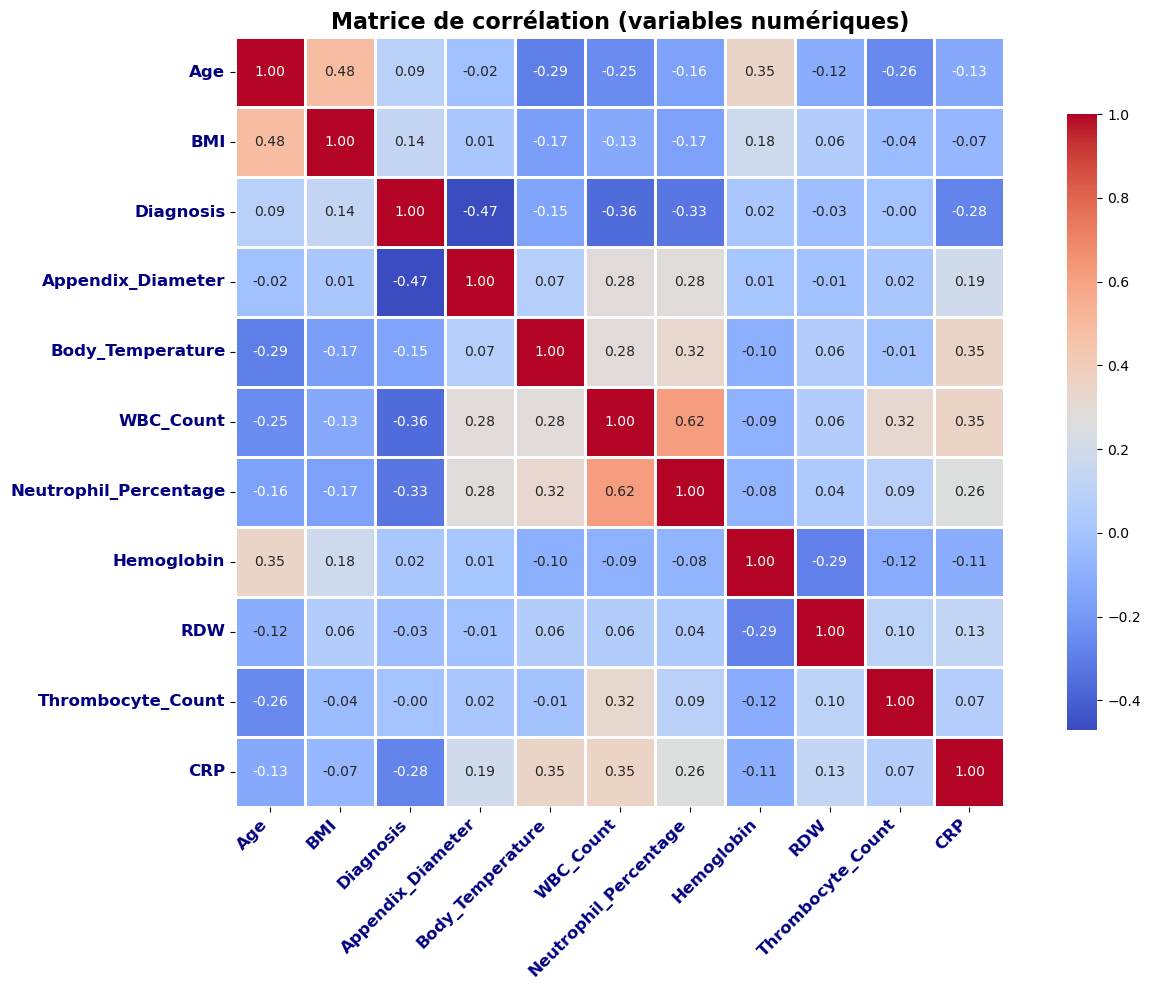

In [31]:
# -----------8.Matrice de corrélation (variables numériques uniquement)--------------------------
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
correlation = df[numerical_cols].corr()
print(correlation)
plt.figure(figsize=(max(14, len(numerical_cols)*0.7), max(10, len(numerical_cols)*0.5)))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    annot_kws={"size": 10},
    linewidths=1,
    linecolor='white',
    cbar_kws={"shrink": 0.8},
    square=True, )
plt.title("Matrice de corrélation (variables numériques)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='navy')
plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='navy')
plt.tight_layout()
plt.show()

                                      Sex_male  Appendix_on_US_yes  \
Sex_male                              1.000000            0.111103   
Appendix_on_US_yes                    0.111103            1.000000   
Migratory_Pain_yes                   -0.000202            0.109012   
Lower_Right_Abd_Pain_yes              0.002154            0.140399   
Contralateral_Rebound_Tenderness_yes -0.039661            0.095037   
Coughing_Pain_yes                    -0.009479            0.068579   
Nausea_yes                            0.025388           -0.009960   
Loss_of_Appetite_yes                  0.022352            0.018940   
Ketones_in_Urine_++                  -0.014005           -0.053576   
Ketones_in_Urine_+++                  0.052530            0.023024   
Ketones_in_Urine_no                  -0.032325            0.029377   
RBC_in_Urine_++                      -0.059305           -0.026452   
RBC_in_Urine_+++                     -0.046852           -0.020798   
RBC_in_Urine_no     

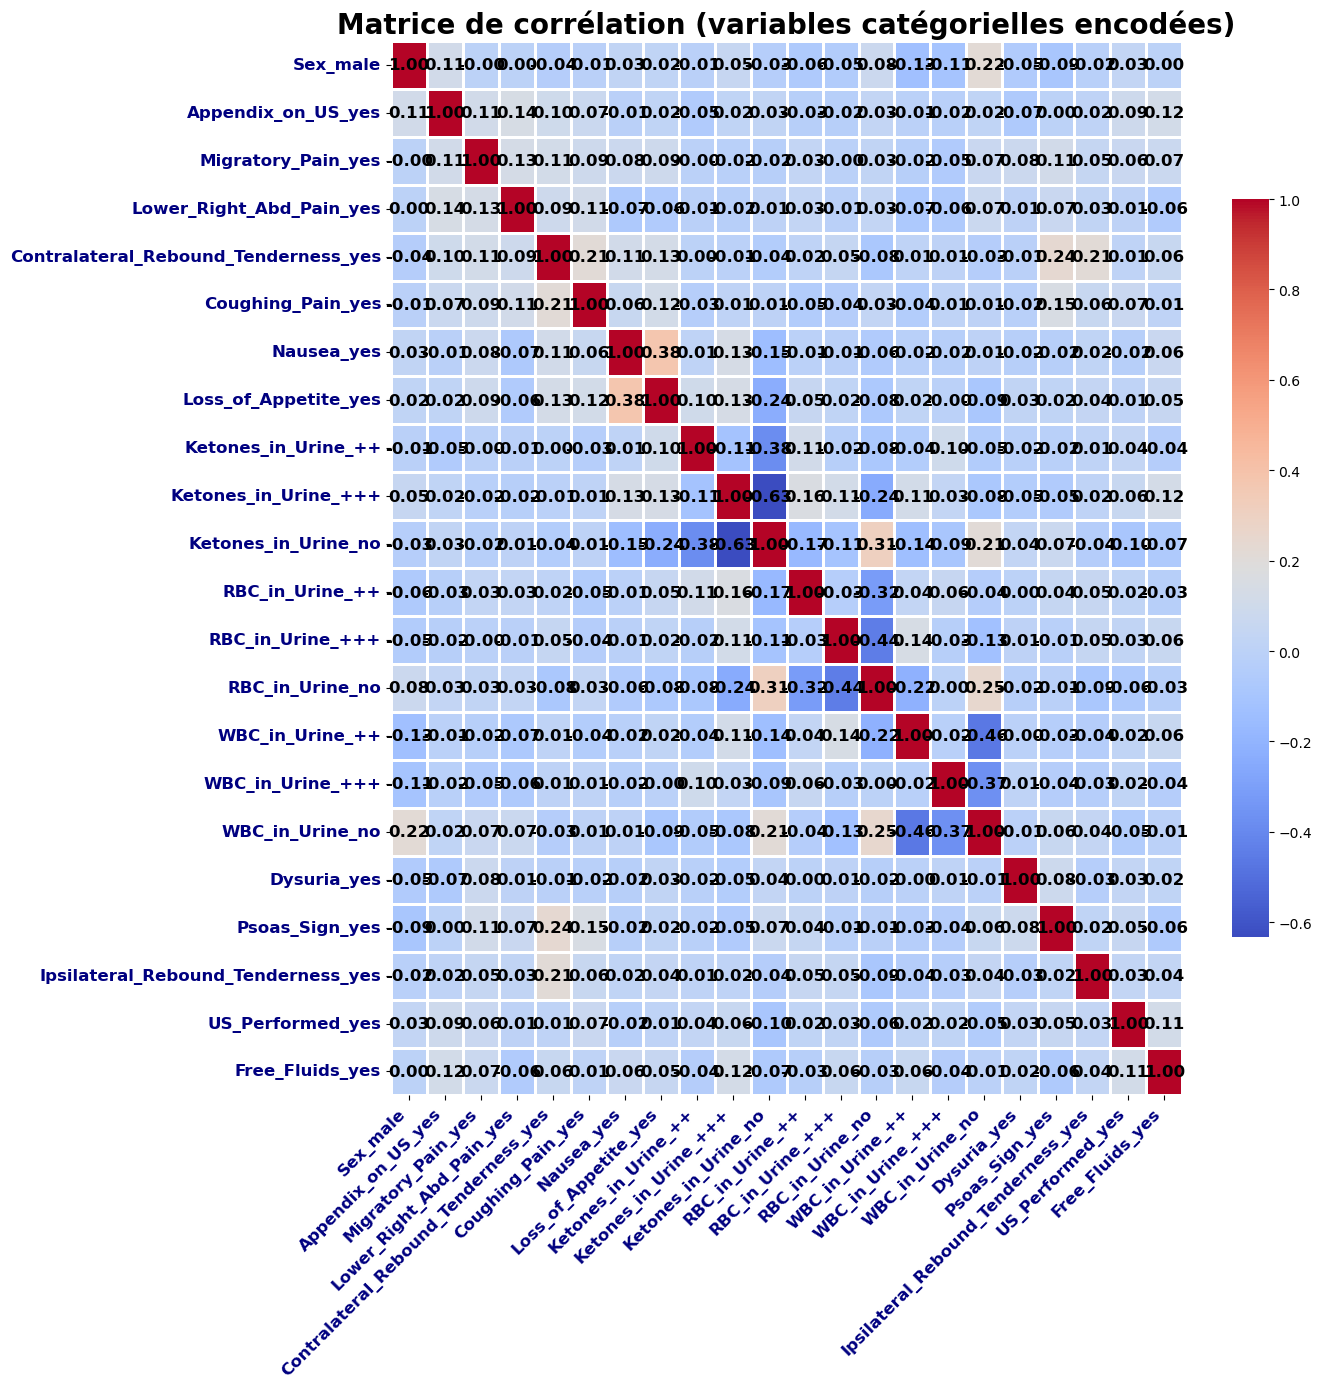

In [32]:
# ----------9.Matrice de corrélation (variables catégorielles encodées uniquement)---------------
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
if categorical_cols:
    df_cat = pd.get_dummies(df[categorical_cols], drop_first=True)
    if not df_cat.empty:
        correlation_cat = df_cat.corr()
        print(correlation_cat)
        plt.figure(figsize=(max(14, len(df_cat.columns)//1.5), max(12, len(df_cat.columns)//1.5)))
        ax = sns.heatmap(
            correlation_cat,
            annot=True,  # Affiche les valeurs sur la heatmap
            fmt=".2f",  # Format des valeurs
            cmap='coolwarm',
            linewidths=1,
            linecolor='white',
            cbar_kws={"shrink": 0.7},
            annot_kws={"size": 12, "color": "black", "weight": "bold"}  # Style des annotations
        )
        plt.title("Matrice de corrélation (variables catégorielles encodées)", fontsize=20, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='navy')
        plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='navy')
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune variable catégorielle encodable.")
else:
    print("Aucune variable catégorielle dans le jeu de données.")

In [33]:
# 10.Couples de variables fortement corrélées (|corr| >= 0.7) sur toutes les variables (numériques + catégorielles encodées)
seuil = 0.7
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
df_cat = pd.get_dummies(df[categorical_cols], drop_first=True) if categorical_cols else pd.DataFrame()
if not df_cat.empty:
    df_total = pd.concat([df[numerical_cols], df_cat], axis=1)
else:
    df_total = df[numerical_cols]
correlation_matrix_total = df_total.corr().abs()
mask = np.triu(np.ones(correlation_matrix_total.shape), k=1).astype(bool)
corr_pairs = correlation_matrix_total.where(mask)
fortement_corr = corr_pairs.stack().sort_values(ascending=False)
print("Couples de variables fortement corrélées (|corr| >= 0.7) :")
print(fortement_corr[fortement_corr >= seuil])
liste_couples = [(var1, var2, corr) for (var1, var2), corr in fortement_corr.items() if corr >= seuil]
print("Liste des couples de variables fortement corrélées :")
print(liste_couples)

Couples de variables fortement corrélées (|corr| >= 0.7) :
Series([], dtype: float64)
Liste des couples de variables fortement corrélées :
[]


In [34]:
#La matrice finale et le fichier excel apres les étapes de nettoyage et d'analyse sont affichés et exportés
print("La matrice finale est de taille")
print(df.shape) 
print("Les colonnes restantes")    
print(df.columns.tolist) 
df.head(5)   

La matrice finale est de taille
(776, 27)
Les colonnes restantes
<bound method IndexOpsMixin.tolist of Index(['Age', 'BMI', 'Sex', 'Diagnosis', 'Appendix_on_US', 'Appendix_Diameter',
       'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Hemoglobin', 'RDW', 'Thrombocyte_Count',
       'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria',
       'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed',
       'Free_Fluids'],
      dtype='object')>


,Age,BMI,Sex,Diagnosis,Appendix_on_US,Appendix_Diameter,Migratory_Pain,Lower_Right_Abd_Pain,Contralateral_Rebound_Tenderness,Coughing_Pain,...,Thrombocyte_Count,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Psoas_Sign,Ipsilateral_Rebound_Tenderness,US_Performed,Free_Fluids
0,12.68,16.90000,female,0,yes,7.1,no,yes,yes,no,...,254.0,++,+,no,0.0,no,yes,no,yes,no
1,14.10,28.85679,male,1,no,7.5,yes,yes,yes,no,...,151.0,no,no,no,3.0,yes,yes,no,yes,no
2,14.14,23.30000,female,1,no,7.5,no,yes,yes,no,...,300.0,no,no,no,3.0,no,yes,no,yes,no
3,16.37,20.60000,female,1,no,7.5,yes,yes,no,no,...,258.0,no,no,no,0.0,yes,yes,no,yes,no
4,11.08,16.90000,female,0,yes,7.0,no,yes,yes,yes,...,311.0,no,no,no,0.0,no,yes,no,yes,no
